In [6]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [5]:
browsers = ['brave', 'safari', 'tor', 'chrome', 'firefox']
conditions = ['easy', 'medium', 'hard', 'throttled']

# Load all metrics.csv files
metrics_dfs = []
for browser in browsers:
    for condition in conditions:
        path = f"metrics/{browser}/{condition}.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['browser'] = browser
            df['condition'] = condition
            metrics_dfs.append(df)
metrics_df = pd.concat(metrics_dfs, ignore_index=True)

# Load all summary.csv files
summary_dfs = []
for browser in browsers:
    for condition in conditions:
        path = f"metrics/{browser}/{condition}_summary.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['browser'] = browser
            df['condition'] = condition
            summary_dfs.append(df)
summary_df = pd.concat(summary_dfs, ignore_index=True)

# Load all mime.csv files
mime_dfs = []
for browser in browsers:
    for condition in conditions:
        path = f"metrics/{browser}/{condition}_mime.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['browser'] = browser
            df['condition'] = condition
            mime_dfs.append(df)
mime_df = pd.concat(mime_dfs, ignore_index=True)

print(metrics_df.shape)
print(summary_df.shape)
print(mime_df.shape)



(300, 14)
(138, 25)
(1034, 6)


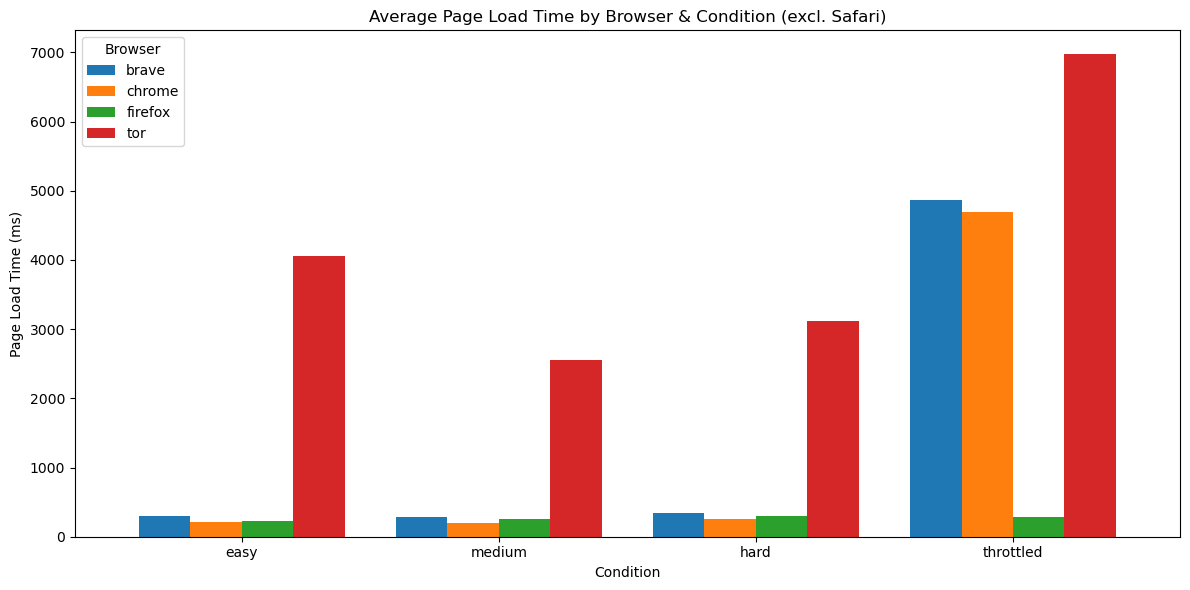

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

# Exclude Safari
filtered_df = metrics_df[metrics_df['browser'] != 'safari']

plt_data = filtered_df.groupby(['browser', 'condition'])['plt_ms'].mean().reset_index()
pivot = plt_data.pivot(index='condition', columns='browser', values='plt_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])

pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Page Load Time by Browser & Condition (excl. Safari)')
ax.set_xlabel('Condition')
ax.set_ylabel('Page Load Time (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

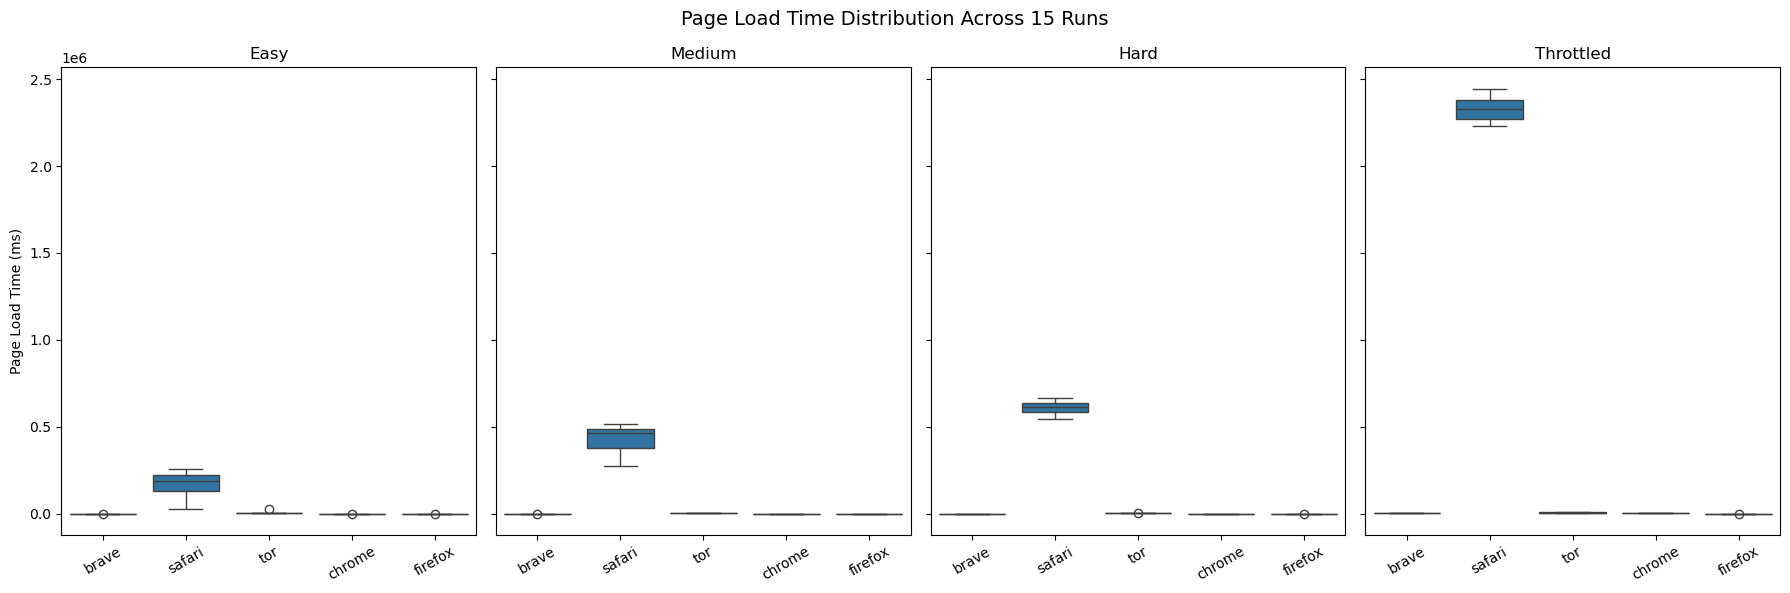

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

for i, condition in enumerate(conditions):
    data = metrics_df[metrics_df['condition'] == condition]
    sns.boxplot(data=data, x='browser', y='plt_ms', ax=axes[i])
    axes[i].set_title(f'{condition.capitalize()}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].set_ylabel('Page Load Time (ms)')
    else:
        axes[i].set_ylabel('')

fig.suptitle('Page Load Time Distribution Across 15 Runs', fontsize=14)
plt.tight_layout()
plt.show()

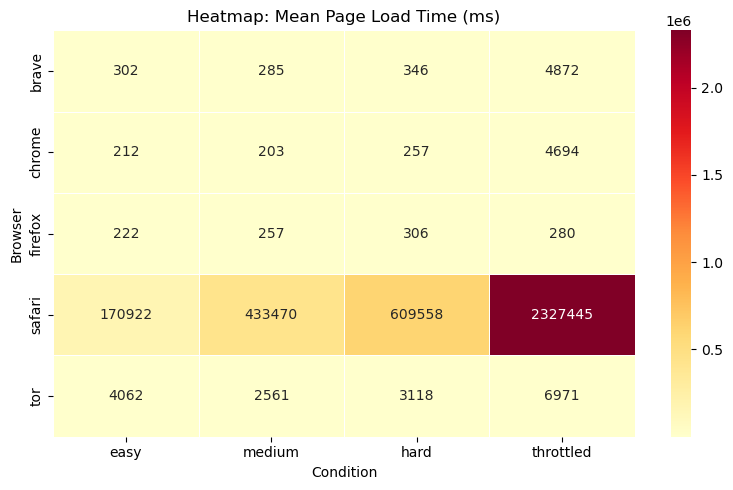

In [22]:
plt_mean = metrics_df.groupby(['browser', 'condition'])['plt_ms'].mean().unstack()
plt_mean = plt_mean[['easy', 'medium', 'hard', 'throttled']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(plt_mean, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap: Mean Page Load Time (ms)')
ax.set_xlabel('Condition')
ax.set_ylabel('Browser')
plt.tight_layout()
plt.show()

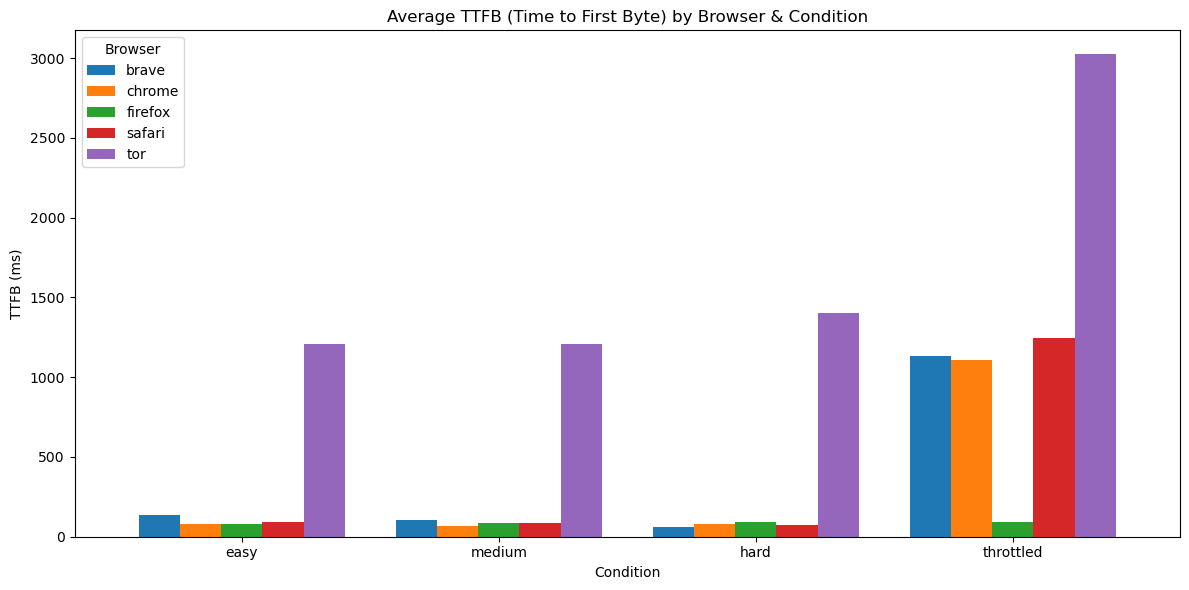

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

ttfb_data = metrics_df.groupby(['browser', 'condition'])['ttfb_ms'].mean().reset_index()
pivot = ttfb_data.pivot(index='condition', columns='browser', values='ttfb_ms')
pivot = pivot.reindex(['easy', 'medium', 'hard', 'throttled'])

pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average TTFB (Time to First Byte) by Browser & Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('TTFB (ms)')
ax.legend(title='Browser')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

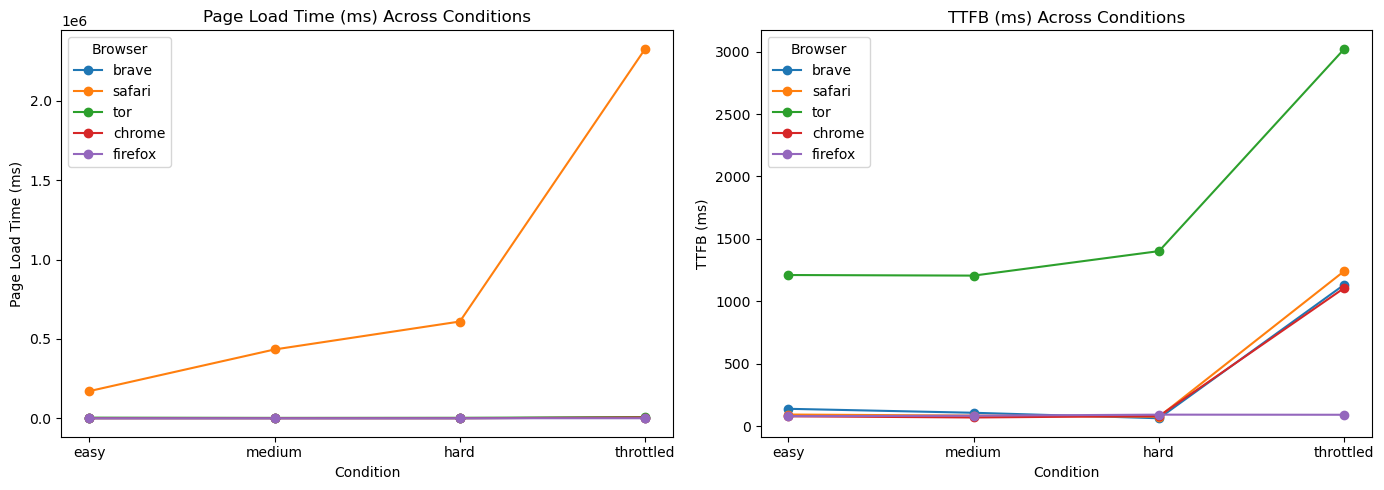

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(axes, ['plt_ms', 'ttfb_ms'], ['Page Load Time (ms)', 'TTFB (ms)']):
    for browser in browsers:
        data = metrics_df[metrics_df['browser'] == browser].groupby('condition')[metric].mean()
        data = data.reindex(['easy', 'medium', 'hard', 'throttled'])
        ax.plot(data.index, data.values, marker='o', label=browser)
    ax.set_title(f'{label} Across Conditions')
    ax.set_xlabel('Condition')
    ax.set_ylabel(label)
    ax.legend(title='Browser')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()